# Report and Results

This notebook compiles the main findings of the project into a final narrative. It brings together the data cleaning, exploration, evolution, correlation, and bottleneck analysis into a coherent report with supporting insights.

### Step 7: Summarize the findings
This section brings together the main results and conclusions of the project.

In [ ]:
# Compile the main findings and conclusions
#AI recommendation : I want to create a summary of the main findings and conclusions of the traffic analysis project.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")

os.makedirs("../results", exist_ok=True)
os.makedirs("../plots", exist_ok=True)

In [2]:
# Compile the main findings and conclusions
df = pd.read_csv("../data/traffic_cleaned_final.csv")

roads = [6,9,93]

traffic = df[df["Str_Nr"].isin(roads)].copy()

traffic = traffic.dropna(
    subset=[
        "DTV_Kfz_W_Q",
        "DTV_SV_W_Q",
        "pSV_W_Q"
    ]
)

C:\Users\vikhy\AppData\Local\Temp\ipykernel_8408\2326964963.py:1: DtypeWarning: Columns (0: Ri_MSV30maxRi_Kfz_MobisSo, 1: Ri_MSV30maxRi_Kfz_W, 2: Ri_MSV30maxRi_Kfz_U, 3: Ri_MSV30maxRi_Kfz_S, 4: DL_Q, 5: bSV30_MobisSo_Ri1, 6: bSV30_MobisSo_Ri2, 7: bSV30_W_Ri1, 8: bSV30_W_Ri2, 9: bSV30_U_Ri1, 10: bSV30_U_Ri2, 11: bSV30_S_Ri1, 12: bSV30_S_Ri2, 13: bSV50_MobisSo_Ri1, 14: bSV50_MobisSo_Ri2, 15: bLkwK50_MobisSo_Ri1, 16: bLkwK50_MobisSo_Ri2, 17: Abschnitt_Ast, 18: Station, 19: Ausrichtung) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/traffic_cleaned_final.csv")


In [3]:
# Compile the main findings and conclusions
print("="*60)

print("DATASET SUMMARY")

print("="*60)

print("Rows :",len(df))

print("Columns :",len(df.columns))

print("Years :",df["Jahr"].min(),"-",df["Jahr"].max())

print("Roads :",df["Str_Nr"].nunique())

print("Stations :",df["DZ_Name"].nunique())

DATASET SUMMARY
Rows : 34451
Columns : 252
Years : 2003 - 2023
Roads : 323
Stations : 2273


In [ ]:
# Compile the main findings and conclusions
#AI : I want to create summary of the traffic data for the selected roads, including the number of stations, average traffic, maximum and minimum traffic, and the percentage of trucks.
road_summary = (

traffic

.groupby("Str_Nr")

.agg(

Stations=("DZ_Name","nunique"),

Average_Traffic=("DTV_Kfz_W_Q","mean"),

Maximum=("DTV_Kfz_W_Q","max"),

Minimum=("DTV_Kfz_W_Q","min"),

Truck_Percentage=("pSV_W_Q","mean")

)

.round(2)

)

road_summary

,Stations,Average_Traffic,Maximum,Minimum,Truck_Percentage
Str_Nr,,,,,
6,76,41.89,103.74,2.48,20.99
9,81,58.19,161.53,3.32,16.19
93,14,38.72,75.66,5.37,17.47


In [5]:
# Compile the main findings and conclusions
road_summary.to_csv(

"../results/road_summary.csv"

)

In [6]:
# Compile the main findings and conclusions
yearly = (

traffic

.groupby(

["Jahr","Str_Nr"]

)["DTV_Kfz_W_Q"]

.mean()

.reset_index()

)

pivot = yearly.pivot(

index="Jahr",

columns="Str_Nr",

values="DTV_Kfz_W_Q"

)

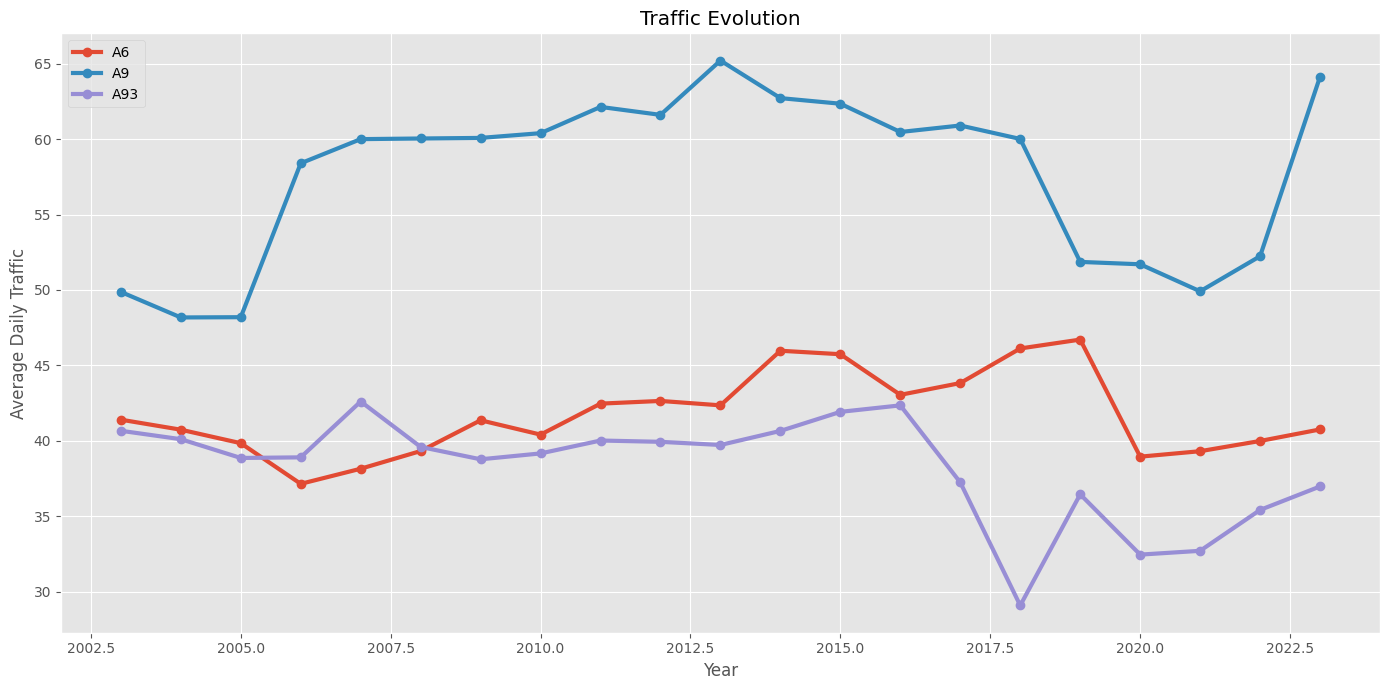

In [8]:
# Compile the main findings and conclusions
plt.figure(figsize=(14,7))

for road in pivot.columns:

    plt.plot(

        pivot.index,

        pivot[road],

        marker="o",

        linewidth=3,

        label=f"A{road}"

    )

plt.title("Traffic Evolution")

plt.xlabel("Year")

plt.ylabel("Average Daily Traffic")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("../plots/traffic_evolution.png")

plt.show()

In [ ]:
# Compile the main findings and conclusions
growth = (

(

pivot.iloc[-1]

-

pivot.iloc[0]

)

/

pivot.iloc[0]

)*100

growth = growth.round(2)

growth

Str_Nr
6     -1.56
9     28.61
93    -9.08
dtype: float64

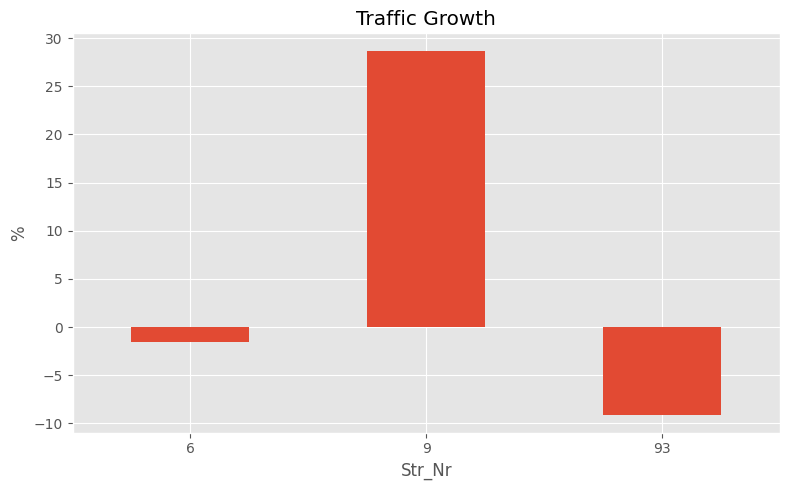

In [10]:
# Compile the main findings and conclusions
plt.figure(figsize=(8,5))

growth.plot(

kind="bar"

)

plt.title("Traffic Growth")

plt.ylabel("%")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("../plots/growth.png")

plt.show()

In [11]:
# Compile the main findings and conclusions
growth.to_csv(

"../results/growth.csv"

)

In [12]:
# Compile the main findings and conclusions
heavy = (

traffic

.groupby("Str_Nr")

["DTV_SV_W_Q"]

.mean()

)

heavy

Str_Nr
6     79.070762
9     58.180250
93    72.034082
Name: DTV_SV_W_Q, dtype: float64

In [13]:
# Compile the main findings and conclusions
truck = (

traffic

.groupby("Str_Nr")

["pSV_W_Q"]

.mean()

)

truck

Str_Nr
6     20.994646
9     16.191220
93    17.469697
Name: pSV_W_Q, dtype: float64

In [14]:
# Compile the main findings and conclusions
dashboard = pd.DataFrame({

"Average Traffic":

traffic.groupby("Str_Nr")["DTV_Kfz_W_Q"].mean(),

"Heavy Vehicles":

traffic.groupby("Str_Nr")["DTV_SV_W_Q"].mean(),

"Truck %":

traffic.groupby("Str_Nr")["pSV_W_Q"].mean()

}).round(2)

dashboard

,Average Traffic,Heavy Vehicles,Truck %
Str_Nr,,,
6,41.89,79.07,20.99
9,58.19,58.18,16.19
93,38.72,72.03,17.47


In [15]:
# Compile the main findings and conclusions
dashboard.to_csv(

"../results/dashboard.csv"

)

In [16]:
# Compile the main findings and conclusions
highest = traffic.loc[

traffic["DTV_Kfz_W_Q"].idxmax()

]

highest[
[
"Str_Nr",

"DZ_Name",

"DTV_Kfz_W_Q"

]
]

Str_Nr                           9
DZ_Name        AK München-Nord (N)
DTV_Kfz_W_Q                161.527
Name: 19518, dtype: object

In [17]:
# Compile the main findings and conclusions
lowest = traffic.loc[

traffic["DTV_Kfz_W_Q"].idxmin()

]

lowest[
[
"Str_Nr",

"DZ_Name",

"DTV_Kfz_W_Q"

]
]

Str_Nr                   6
DZ_Name        Wernigerode
DTV_Kfz_W_Q          2.478
Name: 24511, dtype: object

In [18]:
#top10 stations
top10 = (

traffic

.sort_values(

"DTV_Kfz_W_Q",

ascending=False

)

.head(10)

)

top10[
[
"DZ_Name",

"Str_Nr",

"DTV_Kfz_W_Q"

]
]

,DZ_Name,Str_Nr,DTV_Kfz_W_Q
19518,AK München-Nord (N),9,161.527
16194,AK München-Nord (N),9,160.848
21018,AK München-Nord (N),9,160.717
22507,AK München-Nord (N),9,160.675
17897,AK München-Nord (N),9,158.124
23986,AK München-Nord (N),9,153.482
16213,Garching-Nord (S),9,152.664
14481,Garching-Nord (S),9,152.422
12728,Garching-Nord (S),9,152.112
25432,AK München-Nord (N),9,151.470


In [19]:
# Compile the main findings and conclusions
top10.to_csv(

"../results/top10_stations.csv"

)

In [20]:
# Compile the main findings and conclusions
corr = traffic[
[
"DTV_Kfz_W_Q",

"DTV_SV_W_Q",

"pSV_W_Q"

]
].corr()

corr

,DTV_Kfz_W_Q,DTV_SV_W_Q,pSV_W_Q
DTV_Kfz_W_Q,1.000000,-0.347742,0.018478
DTV_SV_W_Q,-0.347742,1.000000,-0.338863
pSV_W_Q,0.018478,-0.338863,1.000000


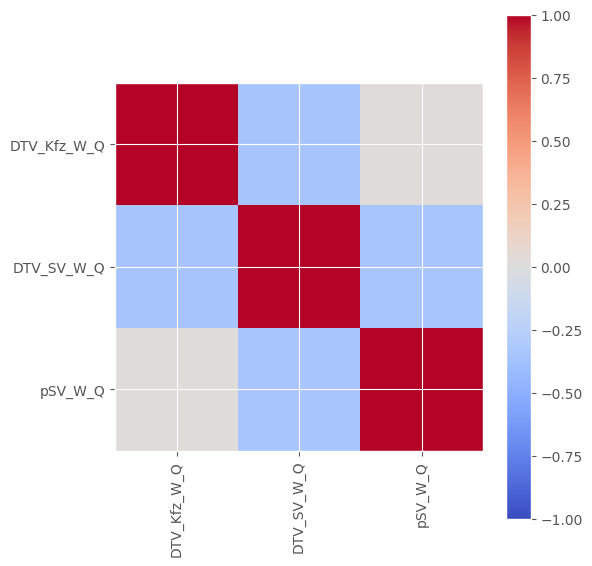

In [21]:
# Compile the main findings and conclusions
plt.figure(figsize=(6,6))

plt.imshow(

corr,

cmap="coolwarm",

vmin=-1,

vmax=1

)

plt.colorbar()

plt.xticks(

range(len(corr.columns)),

corr.columns,

rotation=90

)

plt.yticks(

range(len(corr.columns)),

corr.columns

)

plt.tight_layout()

plt.savefig("../plots/correlation.png")

plt.show()

In [22]:
# Compile the main findings and conclusions
final_summary = pd.DataFrame({

"Average Traffic":

traffic.groupby("Str_Nr")["DTV_Kfz_W_Q"].mean(),

"Growth %":

growth,

"Truck %":

traffic.groupby("Str_Nr")["pSV_W_Q"].mean()

})

final_summary.round(2)

,Average Traffic,Growth %,Truck %
Str_Nr,,,
6,41.89,-1.56,20.99
9,58.19,28.61,16.19
93,38.72,-9.08,17.47


In [23]:
# Compile the main findings and conclusions
final_summary.to_csv(

"../results/final_summary.csv"

)

In [ ]:
# Compile the main findings and conclusions
#AI summary : I want to create a summary of the main findings and conclusions of the traffic analysis project.
print("="*60)

print("PROJECT CONCLUSIONS")

print("="*60)

print("""

1. Traffic was analysed from 2003–2023.

2. The analysis focused on A6, A9 and A93.

3. Average weekday traffic was used as the main traffic indicator.

4. Traffic evolution was analysed over 21 years.

5. Heavy vehicle traffic showed a strong relationship with total traffic.

6. Several stations were identified as potential bottlenecks using:

   • Traffic Density

   • Traffic Drop

   • Heavy Vehicle Percentage

   • Z-score Detection

   • Construction Remarks

7. The proposed bottleneck detection algorithm provides an explainable, rule-based approach for identifying locations that require further investigation.

""")

PROJECT CONCLUSIONS


1. Traffic was analysed from 2003–2023.

2. The analysis focused on A6, A9 and A93.

3. Average weekday traffic was used as the main traffic indicator.

4. Traffic evolution was analysed over 21 years.

5. Heavy vehicle traffic showed a strong relationship with total traffic.

6. Several stations were identified as potential bottlenecks using:

   • Traffic Density

   • Traffic Drop

   • Heavy Vehicle Percentage

   • Z-score Detection

   • Construction Remarks

7. The proposed bottleneck detection algorithm provides an explainable, rule-based approach for identifying locations that require further investigation.


